In [483]:
# ruff: noqa: F401

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

In [484]:
# read in all the words
words = open("../public/names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [485]:
len(words)

32033

In [486]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [487]:
# build the dataset

block_size = (
    3  # context length: how many characters do we take to predict the next one?
)
X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]  # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [488]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [489]:
# build the dataset
block_size = (
    3  # context length: how many characters do we take to predict the next one?
)


def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [490]:
C = torch.randn((27, 2))
C

tensor([[ 0.2953, -0.0068],
        [ 0.6650, -2.1875],
        [-1.6240,  0.0566],
        [-2.4000, -1.4063],
        [ 0.7655,  1.3523],
        [-1.0901,  0.3871],
        [-1.5435, -1.0039],
        [-0.1200, -1.2741],
        [ 0.8580, -0.4718],
        [-1.5419,  0.5535],
        [ 0.3833, -0.2898],
        [ 0.8220,  0.5551],
        [ 0.4910,  0.5749],
        [-0.2422,  2.0079],
        [ 1.2914, -2.8627],
        [-0.1799, -0.1119],
        [-0.7120,  0.7190],
        [-0.6535, -0.8942],
        [ 0.8960, -2.2386],
        [-1.2838,  0.1446],
        [-0.4732,  0.6628],
        [ 1.2279,  0.3342],
        [ 1.8525, -0.2725],
        [ 0.9485,  1.2452],
        [ 1.5276,  0.9009],
        [-1.2297,  0.1837],
        [ 1.1125, -1.1070]])

In [491]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [492]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [493]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h

tensor([[ 0.1347, -0.0950, -0.1798,  ...,  0.4314, -0.8104, -0.8174],
        [-0.3071,  0.9580, -0.7753,  ...,  0.7502, -0.9324, -0.9920],
        [ 0.3480,  0.8881, -0.1939,  ...,  0.9944, -0.9278, -0.9905],
        ...,
        [-0.6468,  0.9995, -0.8891,  ...,  0.9981,  0.4346, -0.9989],
        [ 0.8723,  0.8342, -0.9589,  ...,  0.8354,  0.8864,  0.8394],
        [ 0.3191, -1.0000,  0.9978,  ..., -0.9505, -0.9015, -0.9765]])

In [494]:
h.shape

torch.Size([228146, 100])

In [495]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [496]:
logits = h @ W2 + b2

In [497]:
logits.shape

torch.Size([228146, 27])

In [498]:
counts = logits.exp()

In [499]:
probs = counts / counts.sum(1, keepdim=True)
probs.shape

torch.Size([228146, 27])

In [500]:
probs[0].sum()

tensor(1.)

In [501]:
loss = -probs[torch.arange(emb.shape[0]), Y].log().mean()
loss

tensor(17.9852)

In [502]:
# ------------ now made respectable :) ---------------

In [503]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [504]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [505]:
sum(p.nelement() for p in parameters)  # number of parameters in total

11897

In [506]:
for p in parameters:
    p.requires_grad = True

In [507]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [508]:
lri = []
lossi = []
stepi = []

In [509]:
for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

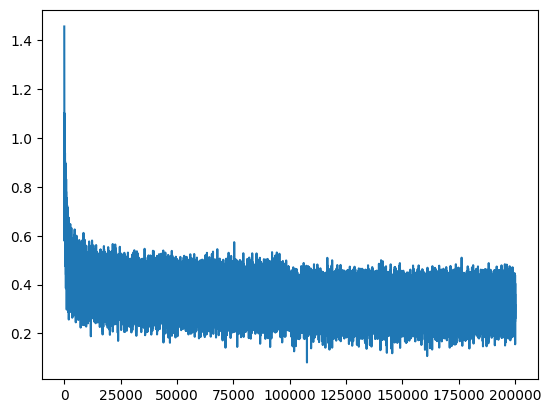

In [510]:
plt.plot(stepi, lossi)

In [511]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.1208395957946777

In [512]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.166886568069458

In [513]:
emb = C[Xte]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss.item()

2.167889356613159

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size  # initialize with all ...
    while True:
        emb = C[torch.tensor([context])]  # (1,block_size,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print("".join(itos[i] for i in out))

carmah.
amelle.
khirmin.
reviyah.
cassie.
rahnee.
deliah.
jareen.
nellara.
chaiivia.
legy.
dham.
join.
quintis.
lilea.
jamii.
wanelo.
dearyni.
jace.
pirsab.
